Note to self. How to compute Rayleigh damping coefficients for given damping ratios $\xi_1$ and $\xi_2$ at frequencies $f_1$ and $f_2$.

This is textbook content, I just need to remind myself too often how this is done and end up re-deriving the equations so I leave this for reference. 

Given the second-order system of differential equations representing the FE model

$$
M \ddot{u} + C \dot{u} + K u = F(t)
$$

The damping matrix $C$ is typically not diagonalizable by the classical (undamped) modes of the system unless it has a specific shape. One way is to use modal damping, that is to assume the ammount of damping for each mode and then deduce the corresponding $C$ by back-projecting or un-diagonalizing the matrix. The problem with that approach is that it often leads to a dense $C$, which is problematic for memory reasons (in large problemas) and because it is non-causal (far-away DOFs end up being coupled through damping). Another option os to forfeit control over the damping for each mode and assume another diagonalizable shape by specifying $C$ as a linear combination of $M$  and $K$. This is called a "Rayleigh" damping matrix:

$$
C = a_0 M + a_1 K
$$

Where $a_0$ and $a_1$ are Rayleigh damping coefficients which are found by specifying the ammout of damping that should occur at specific frequencies $f_1$ and $f_2$ by solving

$$
\left[
\begin{array}{cc}
\dfrac{1}{2\pi f_1} & 2 \pi f_1 \\
\dfrac{1}{2\pi f_2} & 2 \pi f_2 
\end{array}
\right]
\left[
\begin{array}{c}
a_0 \\
a_1
\end{array}
\right]
=
\left[
\begin{array}{c}
\xi_1 \\
\xi_2
\end{array}
\right]
$$

Which I do in the following code:
    

In [2]:
import sympy  as sym


xi1 = sym.S("xi_1")
xi2 = sym.S("xi_2")
xi = sym.S("xi")

f1 = sym.S("f_1")
f2 = sym.S("f_2")

w1 = 2*sym.pi*f1
w2 = 2*sym.pi*f2


A = sym.Matrix([[ 1/w1, w1],[1/w2, w2]])/2
b = sym.Matrix([[xi1],[xi2] ])

a = A**-1*b


print(sym.pretty(sym.simplify(a[0])))
print(sym.simplify(a[0]))
print(sym.pretty(sym.simplify(a[1])))
print(sym.simplify(a[1]))

4⋅π⋅f₁⋅f₂⋅(f₁⋅ξ₂ - f₂⋅ξ₁)
─────────────────────────
          2     2        
        f₁  - f₂         
4*pi*f_1*f_2*(f_1*xi_2 - f_2*xi_1)/(f_1**2 - f_2**2)
f₁⋅ξ₁ - f₂⋅ξ₂
─────────────
  ⎛  2     2⎞
π⋅⎝f₁  - f₂ ⎠
(f_1*xi_1 - f_2*xi_2)/(pi*(f_1**2 - f_2**2))


The frequencies $f_1$ and $f_2$ are usually chosen to match the smallest and largest frequency of the set of eigen-modes of the structure. In problems with large ammount of DOFs you might want to have $f_1$ correspond to the fist eigenmode and $f_2$ to that of the largest eigenfrequency of the subset of eigenmodes you're willing to consider. For wave-propagation purposes I tend to have $f_1$ correspond to the frequency of the longest period wave I want to consider and $f_2$ is set at the limit of the resolution of the mesh for wave-propagation. You can have this be variable thorughout the mesh too, but that's another topic. 

Once two frequencies have been set, damping at other frequencies is given by,

$$
\xi(f) = \dfrac{a_0}{2\pi f} + \pi a_1 f
$$

For example for $f_1 = 0.3$ Hz and $f_2 = 1.2$ Hz, and $\xi_1 = 0.05$, $\xi_2 = 0.02$.

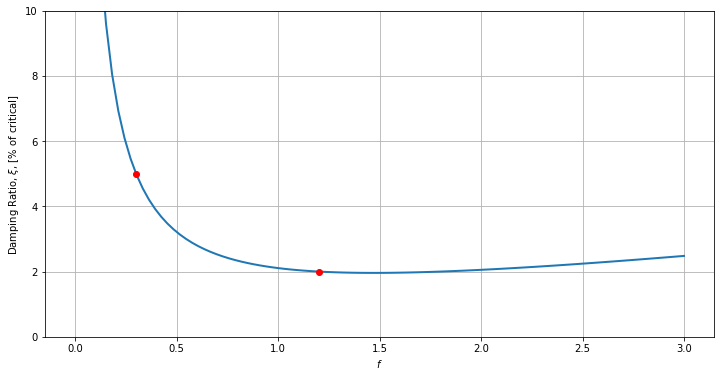

In [7]:
from matplotlib.pylab import *

f_1 = 0.3
f_2 = 1.2
xi_1 = 0.05
xi_2 = 0.02

a_0 = 4*pi*f_1*f_2*(f_1*xi_2 - f_2*xi_1)/(f_1**2 - f_2**2)
a_1 = (f_1*xi_1 - f_2*xi_2)/(pi*(f_1**2 - f_2**2))


f = linspace(0.0001, 3, 100)
xi = a_0/(4*pi*f) + pi*a_1*f

figure().set_size_inches([12,6],forward = True)
plot(f,xi*100, linewidth =2)
plot(f_1, xi_1*100, "ro")
plot(f_2, xi_2*100, "ro")
xlabel(r"$f$")
ylabel(r"Damping Ratio, $\xi$, [% of critical]")
ylim([0,10])
grid()
